In [1]:
import tensorflow as tf
import pandas as pd
import os
import random
import numpy as np

tf.keras.backend.set_floatx("float32")

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["TF_DETERMINISTIC_OPS"] = "1"
os.environ["TF_CUDNN_DETERMINISTIC"] = "1"

os.environ["CUDA_VISIBLE_DEVICES"] = ""

from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_excel("GPC_Dataset.xlsx")

feature_cols = [
    'FA/binder',
    'CA/Binder',
    'Binder (kg)',
    '% of SiO2',
    '% of CaO',
    '% of Al2O3',
    'liquid/binder ratio',
    'NaOH Molarity',
    'Na2SiO3/  NaOH',
    'Additional Water (%)',
    'SP (% of b)',
    'Curing temp (0 C)'
]

X = df[feature_cols].values.astype(np.float32)

# Time
t = df[['Age']].values.astype(np.float32)

# Target
y = df[['Comp. Strength (Mpa)']].values.astype(np.float32)

X_train, X_test, t_train, t_test, y_train, y_test = train_test_split(
    X, t, y, test_size=0.2, random_state=42
)

X_mean, X_std = X_train.mean(axis=0), X_train.std(axis=0) + 1e-6
t_mean, t_std = t_train.mean(), t_train.std() + 1e-6
y_mean, y_std = y_train.mean(), y_train.std() + 1e-6

# Normalize
X_train_n = (X_train - X_mean) / X_std
t_train_n = (t_train - t_mean) / t_std
y_train_n = (y_train - y_mean) / y_std

X_test_n = (X_test - X_mean) / X_std
t_test_n = (t_test - t_mean) / t_std
y_test_n = (y_test - y_mean) / y_std

In [3]:
class PINN(tf.keras.Model):
    def __init__(self):
        super().__init__()
        self.hidden = [
            tf.keras.layers.Dense(64, activation="tanh"),
            tf.keras.layers.Dense(64, activation="tanh"),
            tf.keras.layers.Dense(64, activation="tanh")
        ]

        self.S_out = tf.keras.layers.Dense(1)
        self.Smax_out = tf.keras.layers.Dense(1)
        self.k_out = tf.keras.layers.Dense(1)

    def call(self, X, t):
        z = tf.concat([X, t], axis=1)
        for layer in self.hidden:
            z = layer(z)

        S = self.S_out(z)
        Smax = self.Smax_out(z)
        k = tf.nn.softplus(self.k_out(z))  # ensures k > 0

        return S, Smax, k


In [4]:
@tf.function
def pinn_loss(model, X, t, y):
    with tf.GradientTape(persistent=True) as tape:
        tape.watch(t)

        S, Smax, k = model(X, t)

        # time derivative dS/dt
        dS_dt = tape.gradient(S, t)

        # data loss
        data_loss = tf.reduce_mean((S - y)**2)

        # physics (ODE) loss
        ode_residual = dS_dt - k * (Smax - S)
        physics_loss = tf.reduce_mean(ode_residual**2)

        # monotonicity loss (dS/dt >= 0)
        mono_loss = tf.reduce_mean(tf.nn.relu(-dS_dt))

        # upper bound loss (S <= Smax)
        bound_loss = tf.reduce_mean(tf.nn.relu(S - Smax))

        total_loss = (
            data_loss
            + 1.0 * physics_loss
            + 0.1 * mono_loss
            + 0.1 * bound_loss
        )

    return total_loss, data_loss, physics_loss


In [5]:
model = PINN()
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)

X_train_tf = tf.convert_to_tensor(X_train_n, dtype=tf.float32)
t_train_tf = tf.convert_to_tensor(t_train_n, dtype=tf.float32)
y_train_tf = tf.convert_to_tensor(y_train_n, dtype=tf.float32)

X_test_tf = tf.convert_to_tensor(X_test_n, dtype=tf.float32)
t_test_tf = tf.convert_to_tensor(t_test_n, dtype=tf.float32)
y_test_tf = tf.convert_to_tensor(y_test_n, dtype=tf.float32)

EPOCHS = 5001

for epoch in range(EPOCHS):
    with tf.GradientTape() as tape:
        loss, d_loss, p_loss = pinn_loss(model, X_train_tf, t_train_tf, y_train_tf)

    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))

    if epoch % 500 == 0:
        print(
            f"Epoch {epoch:5d} | "
            f"Total: {loss.numpy():.4e} | "
            f"Data: {d_loss.numpy():.4e} | "
            f"Physics: {p_loss.numpy():.4e}"
        )


Epoch     0 | Total: 1.3846e+00 | Data: 1.2534e+00 | Physics: 1.0645e-01
Epoch   500 | Total: 6.8113e-02 | Data: 6.3012e-02 | Physics: 5.0376e-03
Epoch  1000 | Total: 3.5051e-02 | Data: 3.2333e-02 | Physics: 2.6657e-03
Epoch  1500 | Total: 2.5349e-02 | Data: 2.3677e-02 | Physics: 1.6268e-03
Epoch  2000 | Total: 2.1023e-02 | Data: 1.9460e-02 | Physics: 1.5348e-03
Epoch  2500 | Total: 1.7848e-02 | Data: 1.6344e-02 | Physics: 1.4744e-03
Epoch  3000 | Total: 1.5167e-02 | Data: 1.4085e-02 | Physics: 1.0503e-03
Epoch  3500 | Total: 1.4075e-02 | Data: 1.2537e-02 | Physics: 1.5011e-03
Epoch  4000 | Total: 1.2131e-02 | Data: 1.1271e-02 | Physics: 8.2797e-04
Epoch  4500 | Total: 1.1466e-02 | Data: 1.0526e-02 | Physics: 9.0717e-04
Epoch  5000 | Total: 1.0461e-02 | Data: 9.6478e-03 | Physics: 7.8536e-04


In [6]:
def predict_strength(model, X, t):
    # normalize using training statistics
    Xn = (X - X_mean) / X_std
    tn = (t - t_mean) / t_std

    S, _, _ = model(
        tf.convert_to_tensor(Xn, dtype=tf.float32),
        tf.convert_to_tensor(tn, dtype=tf.float32)
    )

    # denormalize
    return S.numpy() * y_std + y_mean


In [7]:
y_train_pred = predict_strength(model, X_train, t_train)

y_test_pred = predict_strength(model, X_test, t_test)

In [8]:
y_train_true = y_train.flatten()
y_train_pred = y_train_pred.flatten()

y_test_true = y_test.flatten()
y_test_pred = y_test_pred.flatten()


In [9]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

r2_train = r2_score(y_train_true, y_train_pred)
mse_train = mean_squared_error(y_train_true, y_train_pred)
rmse_train = np.sqrt(mse_train)

r2_test = r2_score(y_test_true, y_test_pred)
mse_test = mean_squared_error(y_test_true, y_test_pred)
rmse_test = np.sqrt(mse_test)

print("Training Metrics")
print(f"R²   : {r2_train:.4f}")
print(f"MSE  : {mse_train:.4f}")
print(f"RMSE : {rmse_train:.4f} MPa\n")

print(" Test Metrics")
print(f"R²   : {r2_test:.4f}")
print(f"MSE  : {mse_test:.4f}")
print(f"RMSE : {rmse_test:.4f} MPa")


Training Metrics
R²   : 0.9904
MSE  : 2.5080
RMSE : 1.5837 MPa

 Test Metrics
R²   : 0.9287
MSE  : 18.7212
RMSE : 4.3268 MPa


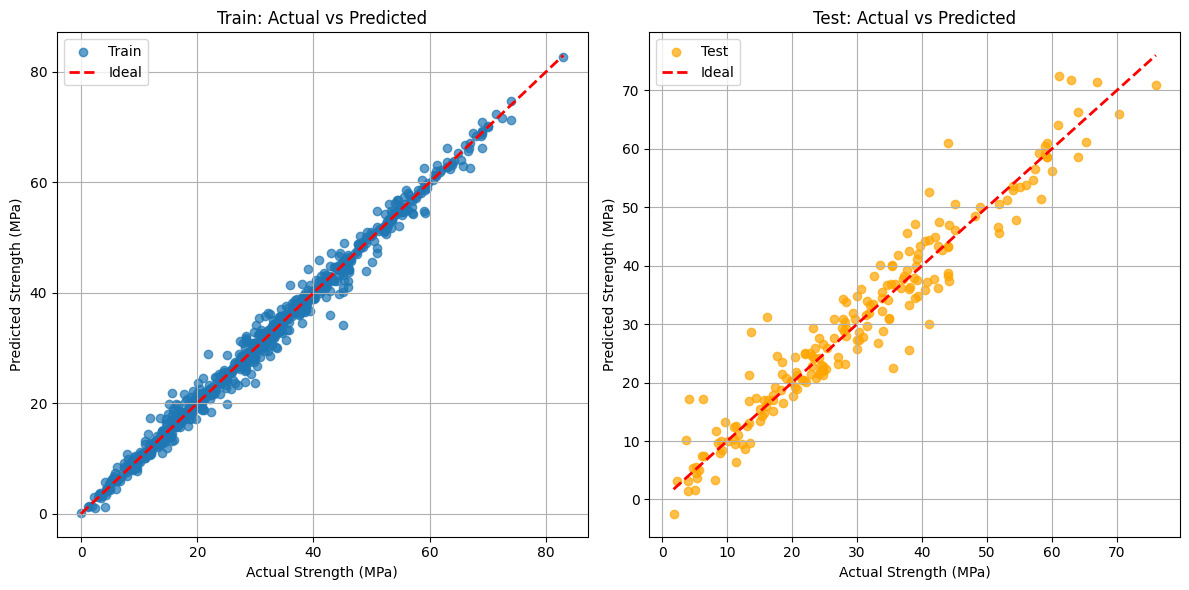

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.scatter(y_train_true, y_train_pred, alpha=0.7, label='Train')
plt.plot(
    [y_train_true.min(), y_train_true.max()],
    [y_train_true.min(), y_train_true.max()],
    'r--', linewidth=2, label='Ideal'
)
plt.xlabel("Actual Strength (MPa)")
plt.ylabel("Predicted Strength (MPa)")
plt.title("Train: Actual vs Predicted")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.scatter(y_test_true, y_test_pred, alpha=0.7, color='orange', label='Test')
plt.plot(
    [y_test_true.min(), y_test_true.max()],
    [y_test_true.min(), y_test_true.max()],
    'r--', linewidth=2, label='Ideal'
)
plt.xlabel("Actual Strength (MPa)")
plt.ylabel("Predicted Strength (MPa)")
plt.title("Test: Actual vs Predicted")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


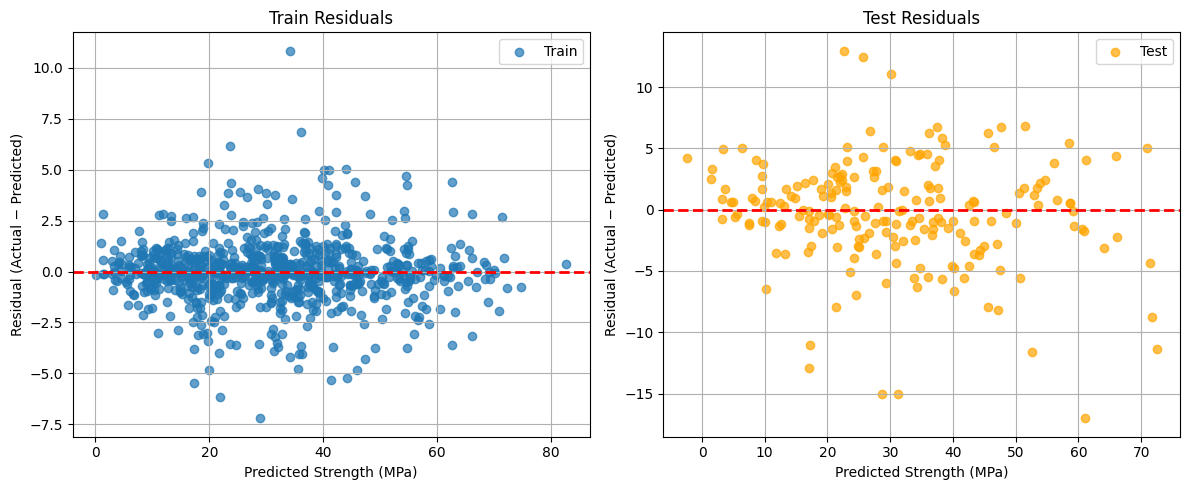

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# residuals
residuals_train = y_train_true - y_train_pred
residuals_test = y_test_true - y_test_pred

plt.subplot(1, 2, 1)
plt.scatter(y_train_pred, residuals_train, alpha=0.7, label='Train')
plt.axhline(0, color='r', linestyle='--', linewidth=2)
plt.xlabel("Predicted Strength (MPa)")
plt.ylabel("Residual (Actual − Predicted)")
plt.title("Train Residuals")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(y_test_pred, residuals_test, alpha=0.7, color='orange', label='Test')
plt.axhline(0, color='r', linestyle='--', linewidth=2)
plt.xlabel("Predicted Strength (MPa)")
plt.ylabel("Residual (Actual − Predicted)")
plt.title("Test Residuals")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()
